In [2]:
import prophet
from prophet.plot import add_changepoints_to_plot
from prophet.utilities import regressor_coefficients

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

from preprocess import load_data, encode_features
from main_prophet import CONFIG
from metrics import *

In [3]:
train_df = load_data(Path(os.getcwd()).parent.parent / CONFIG["data"]["train_path"])
test_df = load_data(Path(os.getcwd()).parent.parent / CONFIG["data"]["test_path"])

train_df, test_df = encode_features(train_df, test_df, resolution=CONFIG["data"]["resolution"])

## Single model, no regressors

In [199]:
m = prophet.Prophet(
    changepoint_prior_scale=0.5,  # Adjust this value to control the flexibility of the trend (higher values allow more changepoints, deafault is 0.05
    yearly_seasonality=True,

)

m.fit(train_df)

future = pd.concat([train_df, test_df], ignore_index=True).drop(columns=['y'])
forecast = m.predict(future)

20:31:56 - cmdstanpy - INFO - Chain [1] start processing
20:31:56 - cmdstanpy - INFO - Chain [1] done processing


In [200]:
preds = forecast[forecast['ds'] >= test_df['ds'].min()].yhat.values
y_true = test_df['y'].values
print(f"MSE: {mse(y_true, preds)}")
print(f"RMSE: {rmse(y_true, preds)}")
print(f"MAE: {mae(y_true, preds)}")

MSE: 54.639662447267405
RMSE: 7.391864612346969
MAE: 6.0761615505959785


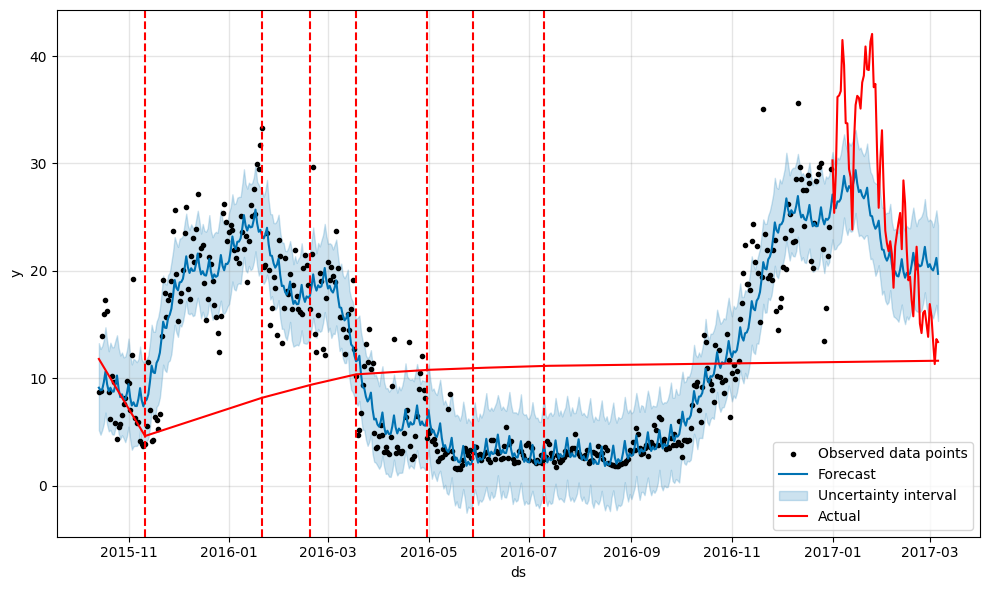

In [201]:
# plot the forecast
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)
plt.plot(test_df['ds'], test_df['y'], 'r-', label='Actual')
plt.legend()
plt.show()


## Single model, with regressors

In [195]:
m = prophet.Prophet(
    changepoint_prior_scale=0.5,  # Adjust this value to control the flexibility of the trend (higher values allow more changepoints, deafault is 0.05
    yearly_seasonality=True,

)

regressor_cols = train_df.columns.difference(['ds', 'y'])
for col in regressor_cols:
    m.add_regressor(col)

m.fit(train_df)

future = pd.concat([train_df, test_df], ignore_index=True).drop(columns=['y'])
forecast = m.predict(future)

20:31:16 - cmdstanpy - INFO - Chain [1] start processing
20:31:16 - cmdstanpy - INFO - Chain [1] done processing


In [196]:
preds = forecast[forecast['ds'] >= test_df['ds'].min()].yhat.values
y_true = test_df['y'].values
print(f"MSE: {mse(y_true, preds)}")
print(f"RMSE: {rmse(y_true, preds)}")
print(f"MAE: {mae(y_true, preds)}")

MSE: 63.991101768246
RMSE: 7.999443841183336
MAE: 6.549057967179753


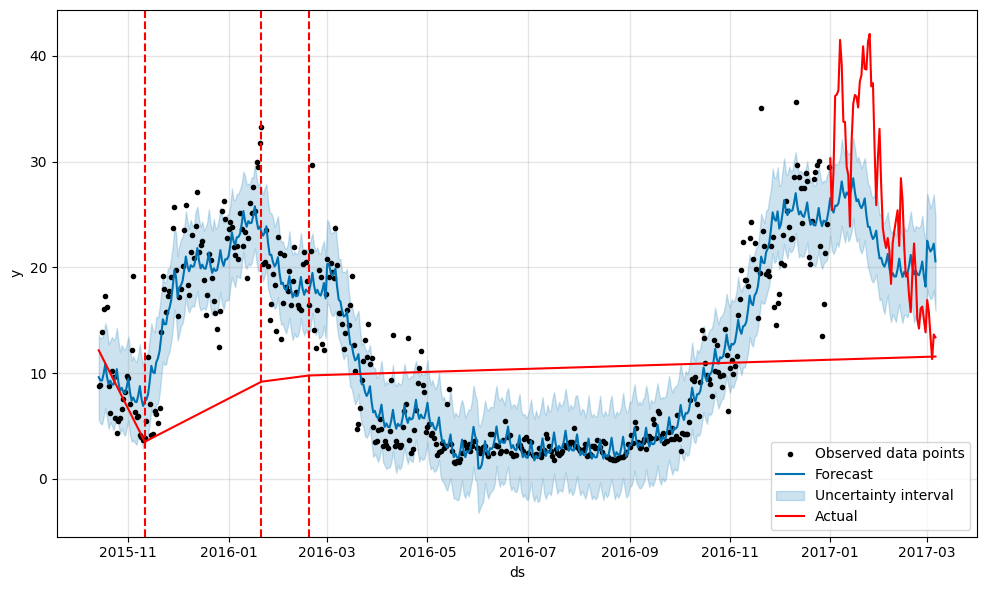

In [198]:
# plot the forecast
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)
plt.plot(test_df['ds'], test_df['y'], 'r-', label='Actual')
plt.legend()
plt.show()


## Refit model

In [9]:
# hyperparameter tuning 
import itertools
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 5, 10],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}

all_params = list(itertools.product(*param_grid.values()))
results = []
regressor_cols = train_df.columns.difference(['ds', 'y'])
for params in all_params:
    param_dict = dict(zip(param_grid.keys(), params))
    m = prophet.Prophet(**param_dict, yearly_seasonality=True)
    for col in regressor_cols:
        m.add_regressor(col)
    m.fit(train_df)
    future = pd.concat([train_df, test_df], ignore_index=True).drop(columns=['y'])
    forecast = m.predict(future)
    preds = forecast[forecast['ds'] >= test_df['ds'].min()].yhat.values
    y_true = test_df['y'].values
    mse_score = mse(y_true, preds)
    results.append((param_dict, mse_score))



21:40:42 - cmdstanpy - INFO - Chain [1] start processing
21:40:42 - cmdstanpy - INFO - Chain [1] done processing
21:40:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:40:42 - cmdstanpy - INFO - Chain [1] start processing
21:40:43 - cmdstanpy - INFO - Chain [1] done processing
21:40:43 - cmdstanpy - INFO - Chain [1] start processing
21:40:43 - cmdstanpy - INFO - Chain [1] done processing
21:40:43 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:40:43 - cmdstanpy - INFO - Chain [1] start processing
21:40:44 - cmdstanpy - INFO - Chain [1] done processing
21:40:44 - cmdstanpy - INFO - Chain [1] start processing
21:40:44 - cmdstanpy - INFO - Chain [1] done processing
21:40:44 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:40:44 - c

In [10]:
results.sort(key=lambda x: x[1])
for params, mse_score in results:
    print(f"Params: {params}, MSE: {mse_score}")

Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1}, MSE: 53.20460201744056
Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0}, MSE: 53.548170536277865
Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0}, MSE: 53.8060663990264
Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0}, MSE: 53.84102981842686
Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.1}, MSE: 54.494855338115116
Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}, MSE: 54.53145896855136
Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}, MSE: 54.57349126975879
Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 1.0}, MSE: 54.592246057959585
Params: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1}, MSE: 54.633668328406934
Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0}, MSE: 57.332054156584974
Params: {'chan

In [11]:
regressor_cols = train_df.columns.difference(['ds', 'y'])
_train_df = train_df.copy()
rows = []
preds = []

for i in range(len(test_df)):
    
    m = prophet.Prophet(
    changepoint_prior_scale=0.01,  # Adjust this value to control the flexibility of the trend (higher values allow more changepoints, deafault is 0.05
    seasonality_prior_scale=0.1,
    scaling='minmax',
    yearly_seasonality=True,

    )
    
    for col in regressor_cols:
        m.add_regressor(col)
        
    m.fit(_train_df)

    _train_df = pd.concat([_train_df, test_df.iloc[i:i+1]], ignore_index=True)
    future = _train_df.drop(columns=['y'])
    
    forecast = m.predict(future)
    next_row = forecast.iloc[-1]
    rows.append(next_row)
    preds.append(next_row['yhat'])

preds = np.array(preds)
forecast = pd.concat([
    forecast.iloc[:-len(test_df)],
    pd.DataFrame(rows, index=test_df.index)
], ignore_index=True)


21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1] done processing
21:41:23 - cmdstanpy - INFO - Chain [1] start processing
21:41:23 - cmdstanpy - INFO - Chain [1]

In [239]:
print(m.changepoint_prior_scale)
print(m.seasonality_prior_scale)
print(m.weekly_seasonality)
print(m.yearly_seasonality)
print(regressor_coefficients(m))

5.0
10.0
auto
True
                    regressor regressor_mode  center  coef_lower      coef  \
0  is_holiday_or_weekend_True       additive     0.0    5.937862  5.937862   
1               season_spring       additive     0.0    1.352581  1.352581   
2               season_summer       additive     0.0   -1.810023 -1.810023   
3               season_winter       additive     0.0   -2.460436 -2.460436   

   coef_upper  
0    5.937862  
1    1.352581  
2   -1.810023  
3   -2.460436  


In [240]:
regressor_coefficients(m)

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,is_holiday_or_weekend_True,additive,0.0,5.937862,5.937862,5.937862
1,season_spring,additive,0.0,1.352581,1.352581,1.352581
2,season_summer,additive,0.0,-1.810023,-1.810023,-1.810023
3,season_winter,additive,0.0,-2.460436,-2.460436,-2.460436


MSE: 38.05896129487586
RMSE: 6.169194541824391
MAE: 5.36844662930953


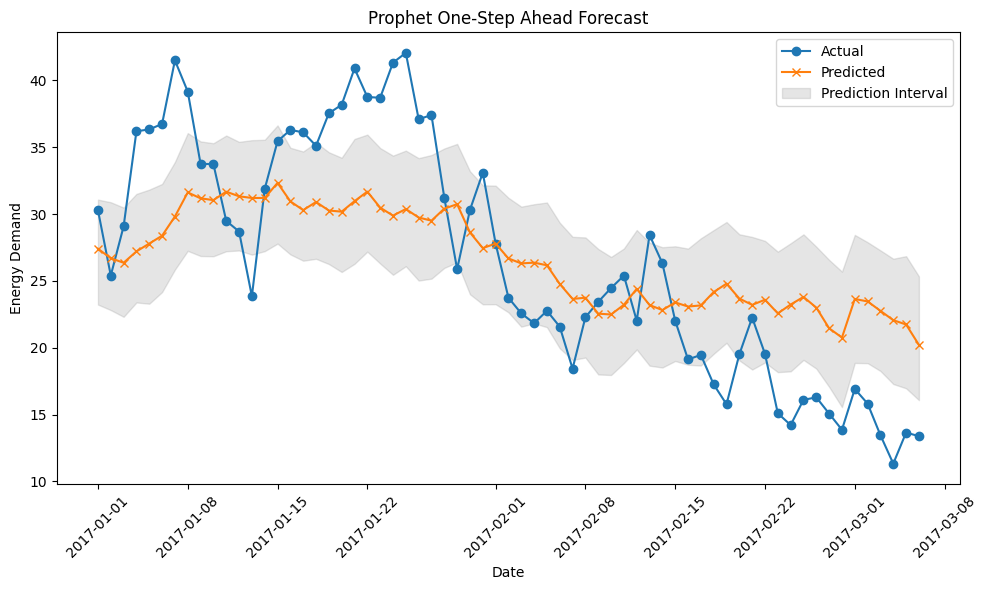

In [12]:
preds = np.array(preds)
y_true = test_df['y'].values
print(f"MSE: {mse(y_true, preds)}")
print(f"RMSE: {rmse(y_true, preds)}")
print(f"MAE: {mae(y_true, preds)}")
# plot predictions vs actual values
plt.figure(figsize=(10, 6))
plt.plot(test_df['ds'], test_df['y'], label='Actual', marker='o')
plt.plot(test_df['ds'], preds, label='Predicted', marker='x')
# plot prediction intervals
plt.fill_between(
    test_df['ds'],
    forecast.iloc[len(train_df):len(train_df)+len(test_df)]['yhat_lower'],
    forecast.iloc[len(train_df):len(train_df)+len(test_df)]['yhat_upper'],
    color='gray', alpha=0.2, label='Prediction Interval')
plt.xlabel('Date')
plt.ylabel('Energy Demand')
plt.title('Prophet One-Step Ahead Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_60304/3650403570.py:4: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')


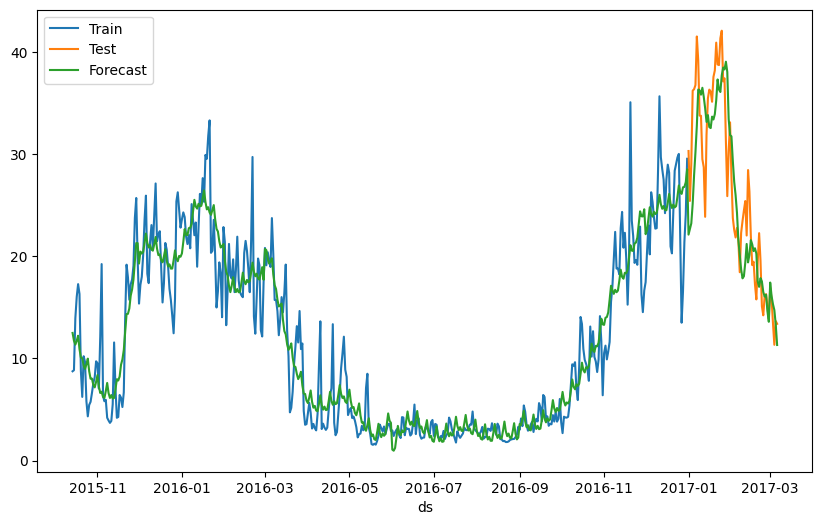

In [232]:
fig, ax = plt.subplots(figsize=(10, 6))
train_df.plot(x='ds', y='y', label='Train', ax=ax)
test_df.plot(x='ds', y='y', label='Test', ax=ax)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.legend()
plt.show()

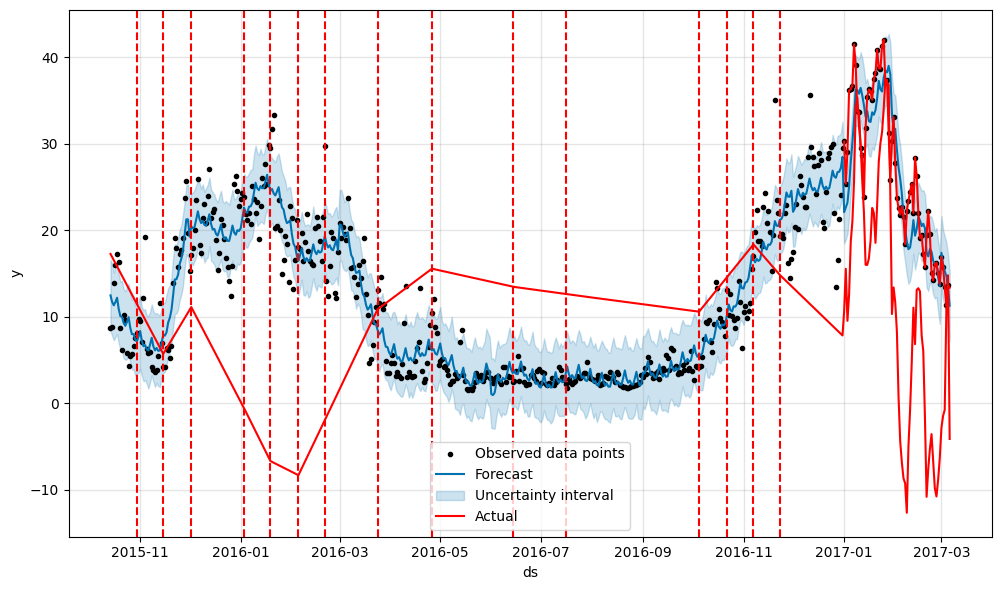

In [241]:
# plot the forecast
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)
plt.plot(test_df['ds'], test_df['y'], 'r-', label='Actual')
plt.legend()
plt.show()


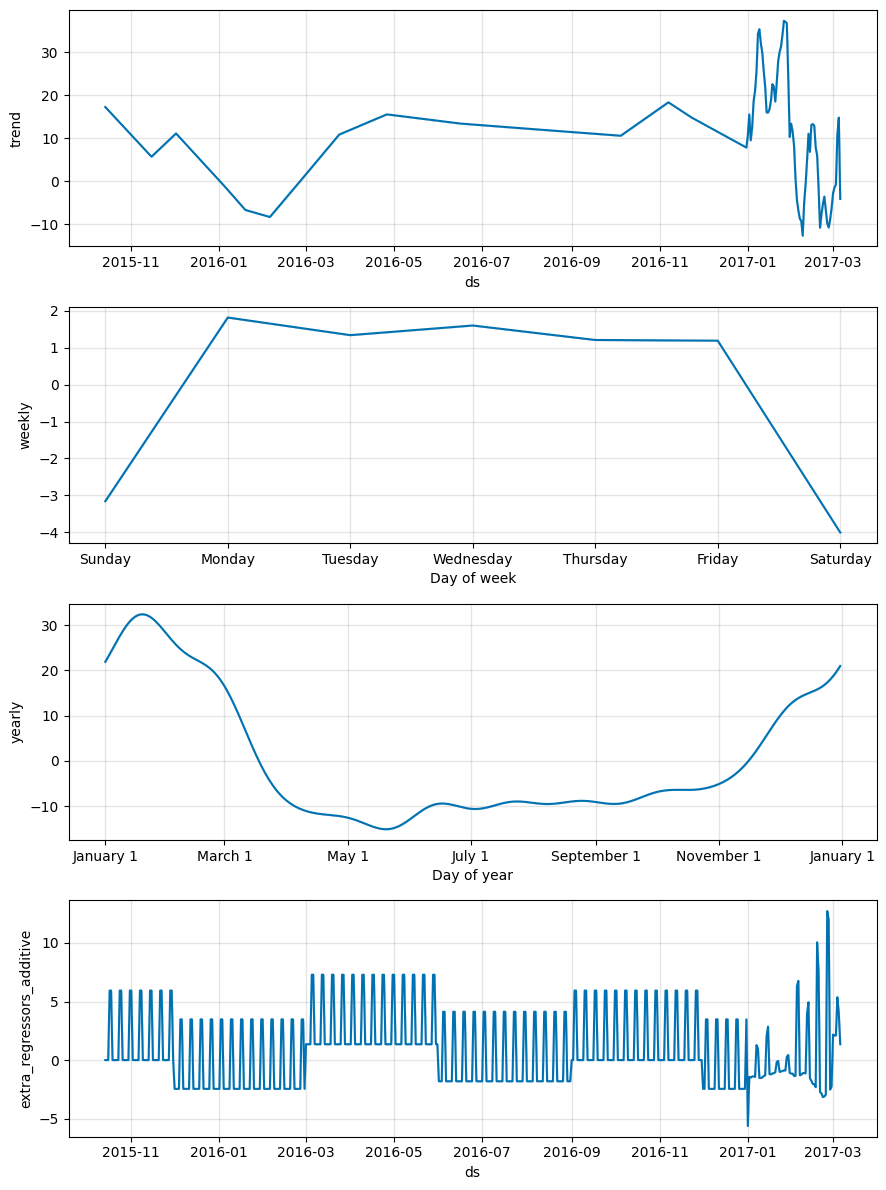

In [242]:
m.plot_components(forecast)
plt.show()